# Predictive Maintenance — NASA CMAPSS Turbofan Engines

**Projet Time Series — ENSIAS, 2026**

---

## Objectif

Construire un système de **maintenance prédictive** pour moteurs d'avion combinant deux objectifs Time Series :

1. **Forecasting** : prédire la durée de vie restante (RUL — *Remaining Useful Life*) à partir des relevés de capteurs.
2. **Détection d'anomalie** : identifier automatiquement le début de la dégradation, **sans étiquette**, à l'aide d'un autoencoder.

## Dataset

**NASA CMAPSS** (*Commercial Modular Aero-Propulsion System Simulation*) — sous-ensembles FD001 (principal) et FD002 (validation sur données plus complexes).

- 100 moteurs simulés en condition *run-to-failure* (FD001)
- 21 capteurs + 3 réglages opérationnels, enregistrés à chaque cycle de vol
- Vérité-terrain RUL dérivée mécaniquement du dernier cycle de chaque moteur

## Méthodologie

Approche **benchmark first** : progression de modèles de complexité croissante, chacun devant battre quantitativement le précédent.

1. EDA et sélection des capteurs informatifs
2. Feature engineering temporel (statistiques glissantes)
3. Baselines naïves (référence du "plancher")
4. Modèle ML — **XGBoost**
5. Modèle DL — **LSTM** sur séquences de 30 cycles
6. Détection d'anomalie non supervisée — **Autoencoder**
7. Comparaison rigoureuse sur jeu de test, métriques RMSE / MAE / **NASA Score**
8. **Validation croisée sur FD002** (scénario à 6 conditions opérationnelles — plus difficile)
9. **Interprétabilité** des prédictions XGBoost via SHAP

## Résultats principaux (FD001)

| Modèle | RMSE (cycles) | MAE |
|---|---|---|
| Baseline Moyenne | 41.94 | 34.83 |
| Régression linéaire (1 capteur) | 23.38 | 19.05 |
| XGBoost (42 features) | 17.84 | 12.62 |
| **LSTM (séquences)** | **14.70** | **11.19** |


## 1. Setup et chargement des données

### 1.1 Installation des librairies

In [1]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1.2 Import des outils

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pour de plus jolis graphes
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Librairies importées")

Librairies importées


### 1.3 Chargement du dataset FD001

Le fichier `train_FD001.txt` contient les trajectoires complètes de 100 moteurs simulés jusqu'à la panne.
Structure : 2 identifiants (`unit`, `cycle`) + 3 réglages opérationnels + 21 capteurs.

In [3]:
# Noms des colonnes : 2 identifiants + 3 réglages + 21 capteurs
colonnes = ["unit", "cycle"] \
    + [f"setting{i}" for i in range(1, 4)] \
    + [f"sensor{i}" for i in range(1, 22)]

# Charger le fichier d'entraînement
train = pd.read_csv(
    "data/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=colonnes
)

print("Dimensions :", train.shape)   # (lignes, colonnes)
train.head()                          # affiche les 5 premières lignes

Dimensions : (20631, 26)


,unit,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Exploration des données (EDA)

### 2.1 Distribution des durées de vie

On commence par observer la variabilité naturelle des moteurs : combien de cycles vit chacun ?

Durée de vie des moteurs :
  Plus court : 128 cycles
  Plus long  : 362 cycles
  Moyenne    : 206 cycles


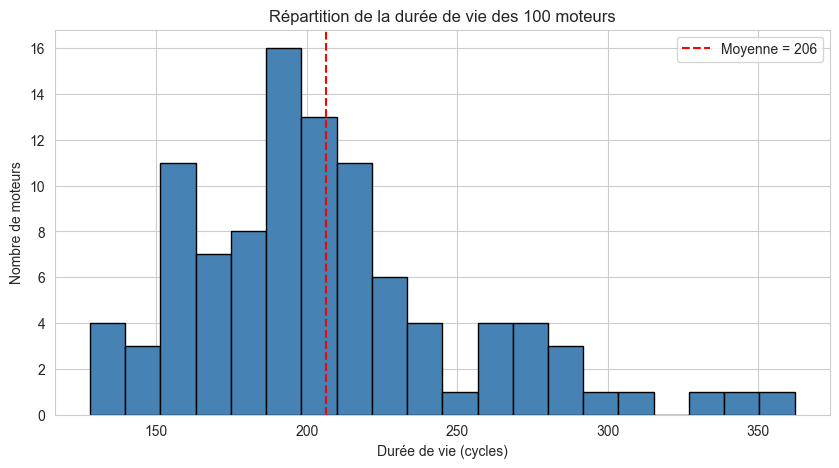

In [4]:
# Durée de vie de chaque moteur = son cycle maximum
duree_vie = train.groupby("unit")["cycle"].max()

print("Durée de vie des moteurs :")
print(f"  Plus court : {duree_vie.min()} cycles")
print(f"  Plus long  : {duree_vie.max()} cycles")
print(f"  Moyenne    : {duree_vie.mean():.0f} cycles")

# Histogramme
plt.figure(figsize=(10, 5))
plt.hist(duree_vie, bins=20, color="steelblue", edgecolor="black")
plt.axvline(duree_vie.mean(), color="red", linestyle="--", label=f"Moyenne = {duree_vie.mean():.0f}")
plt.xlabel("Durée de vie (cycles)")
plt.ylabel("Nombre de moteurs")
plt.title("Répartition de la durée de vie des 100 moteurs")
plt.legend()
plt.show()

**Observation** : les moteurs vivent entre 128 et 362 cycles (moyenne ~206). Cette forte variabilité (du simple au triple) justifie l'approche prédictive : une prédiction "moyenne" ne suffit pas, il faut un modèle qui exploite les capteurs pour estimer l'état individuel de chaque moteur.

### 2.2 Évolution des capteurs au fil de la vie

On vérifie maintenant l'hypothèse centrale du projet : **les capteurs reflètent-ils la dégradation ?**

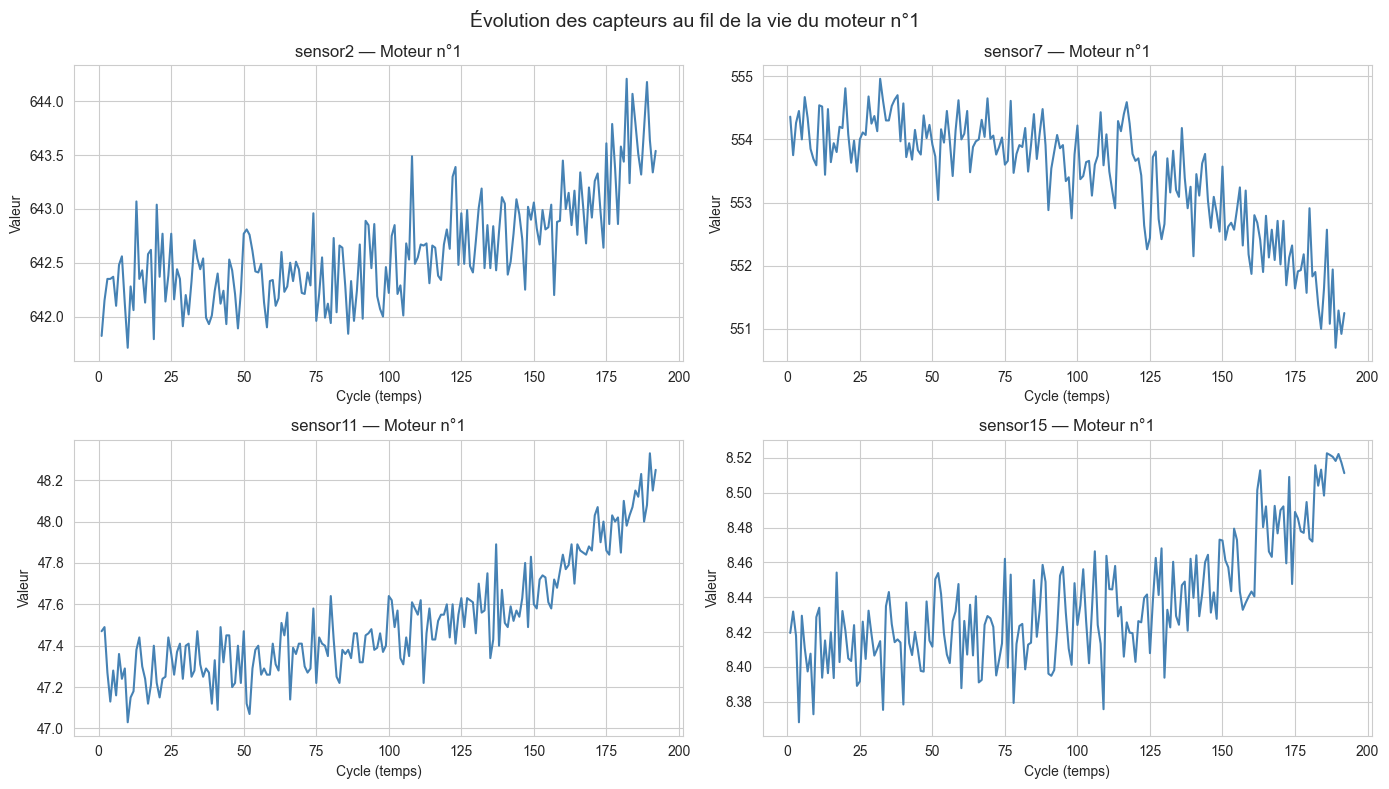

In [5]:
# On isole le moteur n°1
moteur1 = train[train["unit"] == 1]

# On regarde 4 capteurs au hasard pour commencer
capteurs_a_voir = ["sensor2", "sensor7", "sensor11", "sensor15"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, capteur in enumerate(capteurs_a_voir):
    axes[i].plot(moteur1["cycle"], moteur1[capteur], color="steelblue")
    axes[i].set_title(f"{capteur} — Moteur n°1")
    axes[i].set_xlabel("Cycle (temps)")
    axes[i].set_ylabel("Valeur")

plt.suptitle("Évolution des capteurs au fil de la vie du moteur n°1", fontsize=14)
plt.tight_layout()
plt.show()

**Observation** : `sensor2`, `sensor11`, `sensor15` montrent une tendance à la hausse en fin de vie ; `sensor7` une tendance à la baisse. Les capteurs portent bien un signal de dégradation, mais celui-ci est noyé dans du bruit important — d'où la nécessité d'un feature engineering temporel (cf. Partie 3).

### 2.3 Sélection des capteurs informatifs

Un capteur dont la valeur ne varie jamais (écart-type ≈ 0) n'apporte aucune information sur la dégradation. On identifie ces capteurs constants pour les écarter.

In [6]:
# Liste des 21 capteurs
capteurs = [f"sensor{i}" for i in range(1, 22)]

# Écart-type de chaque capteur (mesure de "combien ça bouge")
variation = train[capteurs].std().sort_values()

print("Écart-type de chaque capteur (du plus plat au plus variable) :\n")
print(variation)

Écart-type de chaque capteur (du plus plat au plus variable) :

sensor1     0.000000e+00
sensor10    0.000000e+00
sensor19    0.000000e+00
sensor18    0.000000e+00
sensor16    3.469531e-18
sensor5     5.329200e-15
sensor6     1.388985e-03
sensor15    3.750504e-02
sensor8     7.098548e-02
sensor13    7.191892e-02
sensor21    1.082509e-01
sensor20    1.807464e-01
sensor11    2.670874e-01
sensor2     5.000533e-01
sensor12    7.375534e-01
sensor7     8.850923e-01
sensor17    1.548763e+00
sensor3     6.131150e+00
sensor4     9.000605e+00
sensor14    1.907618e+01
sensor9     2.208288e+01
dtype: float64


**Décision** : on écarte 7 capteurs à variance quasi nulle (`sensor1, 5, 6, 10, 16, 18, 19`). Les **14 capteurs restants** constitueront l'entrée de tous les modèles.

In [7]:
# Capteurs à jeter (écart-type quasi nul)
capteurs_inutiles = ["sensor1", "sensor5", "sensor6", "sensor10",
                     "sensor16", "sensor18", "sensor19"]

# Capteurs utiles = tous les autres
capteurs_utiles = [c for c in capteurs if c not in capteurs_inutiles]

print(f"Nombre de capteurs utiles : {len(capteurs_utiles)}")
print(capteurs_utiles)

Nombre de capteurs utiles : 14
['sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21']


## 3. Construction de la cible RUL

### 3.1 Calcul du RUL brut

Pour chaque ligne, on calcule la durée de vie restante :  
**RUL = (dernier cycle du moteur) − (cycle actuel)**

Au début de vie, le RUL est élevé ; il décroît linéairement jusqu'à 0 (panne).

In [8]:
# Pour chaque moteur, trouver son dernier cycle (= moment de la panne)
train["cycle_max"] = train.groupby("unit")["cycle"].transform("max")

# RUL = dernier cycle - cycle actuel
train["RUL"] = train["cycle_max"] - train["cycle"]

# On vérifie sur le moteur n°1
print("Moteur n°1 — premières lignes :")
print(train[train["unit"] == 1][["unit", "cycle", "cycle_max", "RUL"]].head())

print("\nMoteur n°1 — dernières lignes :")
print(train[train["unit"] == 1][["unit", "cycle", "cycle_max", "RUL"]].tail())

Moteur n°1 — premières lignes :
   unit  cycle  cycle_max  RUL
0     1      1        192  191
1     1      2        192  190
2     1      3        192  189
3     1      4        192  188
4     1      5        192  187

Moteur n°1 — dernières lignes :
     unit  cycle  cycle_max  RUL
187     1    188        192    4
188     1    189        192    3
189     1    190        192    2
190     1    191        192    1
191     1    192        192    0


### 3.2 RUL plafonné (*piecewise linear*)

Un moteur neuf ne présente aucun signe de dégradation : ses capteurs sont stables. Demander au modèle de distinguer "RUL = 191" de "RUL = 160" à partir de capteurs identiques l'amène à apprendre du bruit.

**Solution standard sur CMAPSS** : plafonner le RUL à 125 cycles. Au-delà, le moteur est considéré comme *sain* (RUL = 125). En dessous, le RUL est utilisé normalement.

Cela donne une forme "plateau + descente" qui colle à la réalité physique de la dégradation.

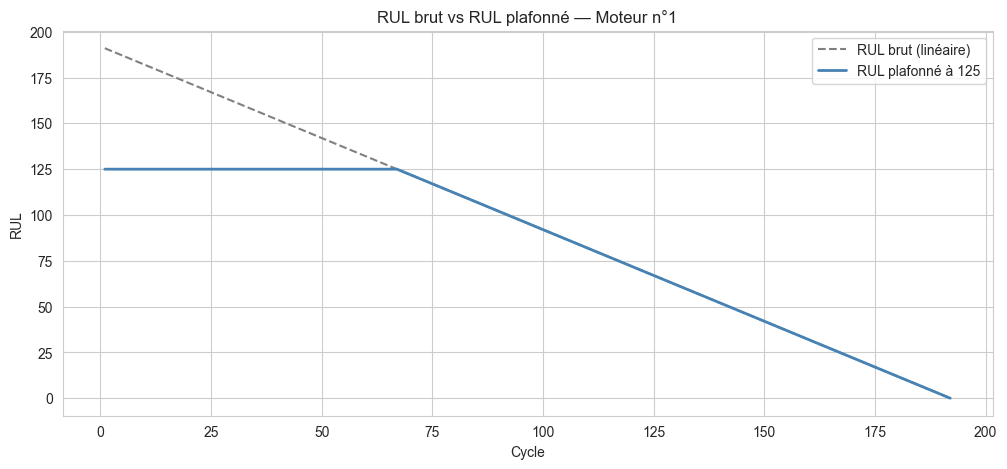

In [9]:
# On plafonne le RUL à 125 (au-delà, le moteur est considéré "sain")
RUL_MAX = 125
train["RUL_clip"] = train["RUL"].clip(upper=RUL_MAX)

# Comparaison visuelle sur le moteur n°1
moteur1 = train[train["unit"] == 1]

plt.figure(figsize=(12, 5))
plt.plot(moteur1["cycle"], moteur1["RUL"], label="RUL brut (linéaire)", linestyle="--", color="gray")
plt.plot(moteur1["cycle"], moteur1["RUL_clip"], label=f"RUL plafonné à {RUL_MAX}", color="steelblue", linewidth=2)
plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title("RUL brut vs RUL plafonné — Moteur n°1")
plt.legend()
plt.show()

**Justification** : cette technique (*piecewise linear RUL*) est référencée dans la littérature CMAPSS (Heimes 2008, Babu et al. 2016) et améliore systématiquement les performances. Elle évite au modèle d'apprendre du bruit sur la phase saine.

## 4. Feature engineering temporel

### 4.1 Problématique

Les capteurs bruts sont très bruités (cf. EDA). Donner une valeur instantanée au modèle revient à lui donner un signal noyé dans du bruit aléatoire.

### 4.2 Solution : statistiques glissantes

Pour chaque capteur, on calcule sur une fenêtre des 5 derniers cycles :
- **Moyenne mobile** (lissage du bruit, révèle la tendance)
- **Écart-type mobile** (détection d'instabilité)

Calcul effectué **par moteur** (`groupby('unit')`) pour éviter toute fuite entre moteurs.

In [10]:
# Taille de la fenêtre glissante
WINDOW = 5

# On part d'une copie pour garder train intact
df = train.copy()

# Pour chaque capteur utile, créer moyenne mobile + écart-type mobile
for capteur in capteurs_utiles:
    # Moyenne mobile (lisse le bruit)
    df[f"{capteur}_mean"] = (
        df.groupby("unit")[capteur]
        .rolling(window=WINDOW, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    # Écart-type mobile (détecte l'instabilité)
    df[f"{capteur}_std"] = (
        df.groupby("unit")[capteur]
        .rolling(window=WINDOW, min_periods=1)
        .std()
        .reset_index(level=0, drop=True)
    )

# Les écart-types du 1er cycle sont vides (NaN) → on les met à 0
df = df.fillna(0)

print("Nouvelles dimensions :", df.shape)
print(f"On est passé de {train.shape[1]} à {df.shape[1]} colonnes")
df.head()

Nouvelles dimensions : (20631, 57)
On est passé de 29 à 57 colonnes


,unit,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor14_mean,sensor14_std,sensor15_mean,sensor15_std,sensor17_mean,sensor17_std,sensor20_mean,sensor20_std,sensor21_mean,sensor21_std
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.620000,0.000000,8.419500,0.000000,392.000000,0.000000,39.060000,0.000000,23.419000,0.000000
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8135.055000,5.041671,8.425650,0.008697,392.000000,0.000000,39.030000,0.042426,23.421300,0.003253
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8134.446667,3.717450,8.423033,0.007640,391.333333,1.154701,39.003333,0.055076,23.395600,0.044573
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8134.292500,3.050906,8.409325,0.028117,391.500000,1.000000,38.972500,0.076322,23.390175,0.037977
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8134.194000,2.651326,8.413340,0.025953,391.800000,1.095445,38.958000,0.073621,23.393020,0.033498


### 4.3 Effet du lissage

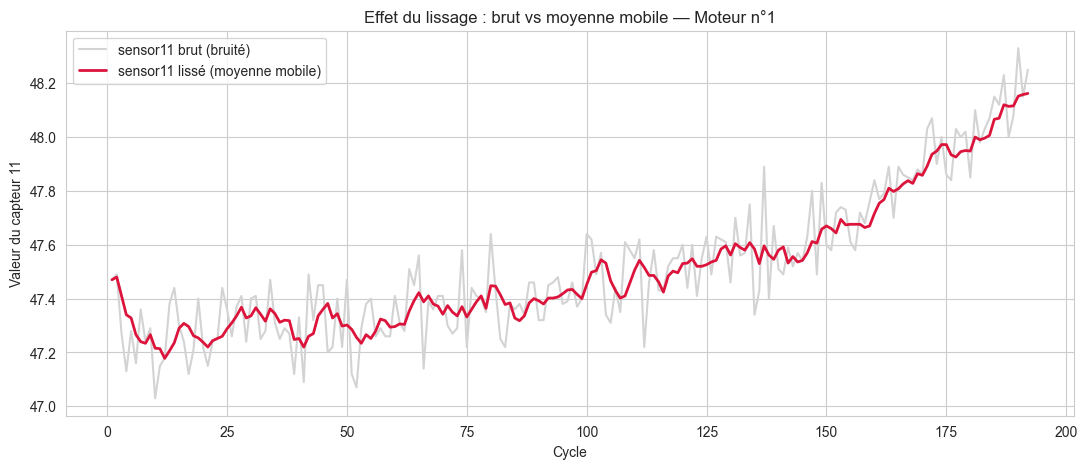

In [11]:
# On reprend le moteur n°1 depuis df (qui contient les features)
m1 = df[df["unit"] == 1]

plt.figure(figsize=(13, 5))
plt.plot(m1["cycle"], m1["sensor11"], color="lightgray", label="sensor11 brut (bruité)")
plt.plot(m1["cycle"], m1["sensor11_mean"], color="crimson", linewidth=2, label="sensor11 lissé (moyenne mobile)")
plt.xlabel("Cycle")
plt.ylabel("Valeur du capteur 11")
plt.title("Effet du lissage : brut vs moyenne mobile — Moteur n°1")
plt.legend()
plt.show()

**Observation** : la version lissée révèle clairement la tendance montante de `sensor11`, invisible dans le signal brut. C'est cette information débruitée qui sera exploitée par les modèles.

## 5. Baselines

Conformément à la méthodologie *benchmark first*, on établit des modèles naïfs servant de **plancher de référence**. Tout modèle plus sophistiqué devra quantitativement battre ces baselines pour justifier sa complexité.

### 5.1 Préparation du jeu de test

Le fichier `test_FD001.txt` contient des trajectoires **tronquées avant la panne**. La cible (vrai RUL au dernier cycle enregistré) est donnée dans `RUL_FD001.txt`.

On applique au test **le même pipeline de features** que sur le train (sans ré-apprendre l'échelle — évite toute fuite).

In [12]:
# 1. Charger le test (mêmes colonnes que le train)
test = pd.read_csv("data/test_FD001.txt", sep=r"\s+", header=None, names=colonnes)

# 2. Charger les vraies réponses RUL
rul_true = pd.read_csv("data/RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"])

print("Test :", test.shape)
print("RUL vrais :", rul_true.shape)

# 3. Appliquer le MÊME feature engineering que sur le train
df_test = test.copy()
for capteur in capteurs_utiles:
    df_test[f"{capteur}_mean"] = (
        df_test.groupby("unit")[capteur]
        .rolling(window=WINDOW, min_periods=1).mean()
        .reset_index(level=0, drop=True)
    )
    df_test[f"{capteur}_std"] = (
        df_test.groupby("unit")[capteur]
        .rolling(window=WINDOW, min_periods=1).std()
        .reset_index(level=0, drop=True)
    )
df_test = df_test.fillna(0)

print("Test avec features :", df_test.shape)

Test : (13096, 26)
RUL vrais : (100, 1)
Test avec features : (13096, 54)


### 5.2 Installation des librairies de modélisation

In [13]:
%pip install scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 5.3 Baseline 0 — Moyenne aveugle

Modèle le plus simple possible : prédire pour tous les moteurs la même valeur (le RUL moyen du train). N'utilise aucun capteur.

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Pour chaque moteur de test, on garde sa DERNIÈRE ligne (état le plus récent)
test_last = df_test.groupby("unit").last().reset_index()
print("Une ligne par moteur de test :", test_last.shape)

# Les vraies réponses (plafonnées comme à l'entraînement, pour comparer équitablement)
y_true = rul_true["RUL"].clip(upper=RUL_MAX).values

# --- BASELINE 0 : prédire toujours la moyenne ---
valeur_moyenne = train["RUL_clip"].mean()
y_pred_baseline = np.full(len(y_true), valeur_moyenne)

# Calcul des scores
rmse = np.sqrt(mean_squared_error(y_true, y_pred_baseline))
mae = mean_absolute_error(y_true, y_pred_baseline)

print(f"\n--- Baseline 'Moyenne' (prédit toujours {valeur_moyenne:.1f}) ---")
print(f"RMSE : {rmse:.2f} cycles")
print(f"MAE  : {mae:.2f} cycles")

Une ligne par moteur de test : (100, 54)

--- Baseline 'Moyenne' (prédit toujours 86.8) ---
RMSE : 41.94 cycles
MAE  : 34.83 cycles


**Résultat** : RMSE = 41.94. C'est notre **plancher de référence**. Tout modèle exploitant les capteurs devra faire significativement mieux.

### 5.4 Baseline 1 — Régression linéaire univariée

Régression linéaire simple sur un seul capteur lissé (`sensor11_mean`). Première utilisation d'information capteur.

In [15]:
from sklearn.linear_model import LinearRegression

# On utilise UN seul capteur lissé comme indice : sensor11_mean
X_train_simple = df[["sensor11_mean"]].values
y_train_simple = df["RUL_clip"].values

# Entraîner une régression linéaire toute simple
lr = LinearRegression()
lr.fit(X_train_simple, y_train_simple)

# Prédire sur la dernière ligne de chaque moteur de test
X_test_simple = test_last[["sensor11_mean"]].values
y_pred_lr = lr.predict(X_test_simple)
y_pred_lr = np.clip(y_pred_lr, 0, RUL_MAX)   # on borne entre 0 et 125

# Scores
rmse_lr = np.sqrt(mean_squared_error(y_true, y_pred_lr))
mae_lr = mean_absolute_error(y_true, y_pred_lr)

print("--- Baseline 'Régression linéaire (1 capteur)' ---")
print(f"RMSE : {rmse_lr:.2f} cycles")
print(f"MAE  : {mae_lr:.2f} cycles")
print(f"\nRappel baseline Moyenne : RMSE = {rmse:.2f}")

--- Baseline 'Régression linéaire (1 capteur)' ---
RMSE : 23.38 cycles
MAE  : 19.05 cycles

Rappel baseline Moyenne : RMSE = 41.94


**Résultat** : RMSE = 23.38, soit une réduction de **44 %** par rapport à la baseline aveugle. Cela confirme empiriquement qu'un capteur lissé porte une information exploitable sur la dégradation.

## 6. Modèle ML — XGBoost

Algorithme de *gradient boosting* sur arbres de décision. État de l'art pour les problèmes de régression tabulaire.

**Entrée** : 42 features par instant (14 capteurs bruts + 14 moyennes mobiles + 14 écarts-types mobiles).
**Sortie** : RUL prédit (instantané).

In [16]:
from xgboost import XGBRegressor

# Toutes les features : capteurs utiles bruts + leurs versions lissées
features = capteurs_utiles \
    + [f"{c}_mean" for c in capteurs_utiles] \
    + [f"{c}_std" for c in capteurs_utiles]

print(f"Nombre de features utilisées : {len(features)}")

# Données d'entraînement
X_train = df[features].values
y_train = df["RUL_clip"].values

# Données de test (dernière ligne de chaque moteur)
X_test = test_last[features].values

# Entraîner XGBoost
xgb = XGBRegressor(
    n_estimators=100,      # nombre d'arbres
    max_depth=5,           # profondeur de chaque arbre
    learning_rate=0.1,     # vitesse d'apprentissage
    random_state=42
)
xgb.fit(X_train, y_train)

# Prédire et borner entre 0 et 125
y_pred_xgb = xgb.predict(X_test)
y_pred_xgb = np.clip(y_pred_xgb, 0, RUL_MAX)

# Scores
rmse_xgb = np.sqrt(mean_squared_error(y_true, y_pred_xgb))
mae_xgb = mean_absolute_error(y_true, y_pred_xgb)

print("\n--- Modèle XGBoost (toutes les features) ---")
print(f"RMSE : {rmse_xgb:.2f} cycles")
print(f"MAE  : {mae_xgb:.2f} cycles")
print(f"\n=== Comparaison ===")
print(f"Baseline Moyenne      : {rmse:.2f}")
print(f"Régression 1 capteur  : {rmse_lr:.2f}")
print(f"XGBoost               : {rmse_xgb:.2f}")

Nombre de features utilisées : 42

--- Modèle XGBoost (toutes les features) ---
RMSE : 17.84 cycles
MAE  : 12.62 cycles

=== Comparaison ===
Baseline Moyenne      : 41.94
Régression 1 capteur  : 23.38
XGBoost               : 17.84


**Résultat** : RMSE = **17.84** — nouvelle amélioration substantielle. XGBoost exploite efficacement l'ensemble des features simultanément.

### 6.1 Importance des features

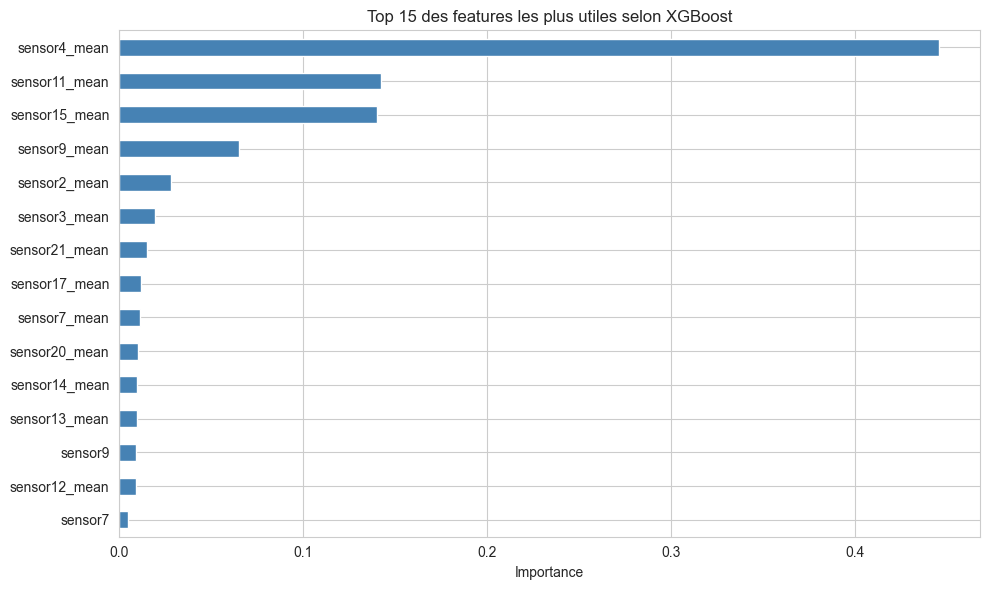

In [17]:
# Récupérer l'importance de chaque feature
importance = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)

# Top 15
plt.figure(figsize=(10, 6))
importance.head(15).plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 15 des features les plus utiles selon XGBoost")
plt.tight_layout()
plt.show()

**Observation** : les features les plus importantes sont essentiellement les **versions lissées** (`_mean`) des capteurs (`sensor4_mean`, `sensor11_mean`, `sensor15_mean`, `sensor9_mean`). Cela valide quantitativement la pertinence du feature engineering temporel (Partie 4).

## 7. Modèle DL — LSTM

### 7.1 Motivation

XGBoost traite chaque instant indépendamment (instantané). Or la dégradation est par nature un phénomène **séquentiel** : la trajectoire des capteurs sur plusieurs cycles est porteuse d'information que le modèle tabulaire ne capture pas.

Le LSTM (*Long Short-Term Memory*) est un réseau de neurones récurrent capable de modéliser des dépendances temporelles dans une séquence.

### 7.2 Installation de PyTorch

In [18]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 7.3 Normalisation des capteurs

Les réseaux de neurones sont sensibles à l'échelle des features. On normalise les 14 capteurs entre 0 et 1 via *MinMaxScaler*, en apprenant l'échelle **uniquement sur le train**.

In [19]:
from sklearn.preprocessing import MinMaxScaler

# On normalise UNIQUEMENT les capteurs utiles bruts (le LSTM lit la séquence brute)
scaler = MinMaxScaler()

# Apprendre l'échelle sur le train, et transformer
df_lstm = df.copy()
df_lstm[capteurs_utiles] = scaler.fit_transform(df[capteurs_utiles])

# Appliquer LA MÊME échelle au test (sans ré-apprendre !)
df_test_lstm = df_test.copy()
df_test_lstm[capteurs_utiles] = scaler.transform(df_test[capteurs_utiles])

print("Normalisation faite ✓")
print("\nAvant (train brut) — sensor4 :")
print(df[capteurs_utiles[2]].describe()[["min", "max"]])
print("\nAprès (train normalisé) — sensor4 :")
print(df_lstm[capteurs_utiles[2]].describe()[["min", "max"]])

Normalisation faite ✓

Avant (train brut) — sensor4 :
min    1382.25
max    1441.49
Name: sensor4, dtype: float64

Après (train normalisé) — sensor4 :
min    0.0
max    1.0
Name: sensor4, dtype: float64


### 7.4 Construction des séquences

Le LSTM prend en entrée des **fenêtres glissantes de 30 cycles** : à chaque instant, il observe les 30 cycles précédents pour prédire le RUL courant.

Pour le test, on utilise les 30 derniers cycles enregistrés de chaque moteur.

In [20]:
import numpy as np

SEQ_LEN = 30   # longueur de la fenêtre (30 cycles)

def creer_sequences_train(data, capteurs, seq_len):
    """Pour le train : toutes les fenêtres glissantes de chaque moteur."""
    X, y = [], []
    for unit in data["unit"].unique():
        moteur = data[data["unit"] == unit]
        valeurs = moteur[capteurs].values
        cibles = moteur["RUL_clip"].values
        # Glisser la fenêtre
        for i in range(len(moteur) - seq_len + 1):
            X.append(valeurs[i:i + seq_len])
            y.append(cibles[i + seq_len - 1])   # RUL au dernier cycle de la fenêtre
    return np.array(X), np.array(y)

def creer_sequences_test(data, capteurs, seq_len):
    """Pour le test : la DERNIÈRE fenêtre de chaque moteur."""
    X = []
    for unit in data["unit"].unique():
        moteur = data[data["unit"] == unit]
        valeurs = moteur[capteurs].values
        if len(valeurs) >= seq_len:
            X.append(valeurs[-seq_len:])         # les 30 derniers cycles
        else:
            # Padding : compléter par le haut si moins de 30 cycles
            pad = np.zeros((seq_len - len(valeurs), len(capteurs)))
            X.append(np.vstack([pad, valeurs]))
    return np.array(X)

# Créer les séquences
X_train_seq, y_train_seq = creer_sequences_train(df_lstm, capteurs_utiles, SEQ_LEN)
X_test_seq = creer_sequences_test(df_test_lstm, capteurs_utiles, SEQ_LEN)

print("Séquences d'entraînement X :", X_train_seq.shape)
print("Cibles d'entraînement y   :", y_train_seq.shape)
print("Séquences de test X       :", X_test_seq.shape)

Séquences d'entraînement X : (17731, 30, 14)
Cibles d'entraînement y   : (17731,)
Séquences de test X       : (100, 30, 14)


### 7.5 Architecture du réseau

Le réseau combine :
- **2 couches LSTM** (hidden size = 64) pour modéliser la dynamique temporelle
- **Dropout 0.2** pour régulariser et limiter le surapprentissage
- **Couche dense finale** projetant vers une seule valeur (RUL prédit)

In [21]:
import torch
import torch.nn as nn

# Vérifier si on a un GPU (sinon CPU, c'est ok pour ce projet)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Calcul sur : {device}")

# Définition du réseau
class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        # 1. La couche LSTM (lit la séquence et garde une mémoire)
        self.lstm = nn.LSTM(
            input_size=n_features,    # 14 capteurs
            hidden_size=hidden_size,  # taille de la "mémoire"
            num_layers=num_layers,    # 2 couches LSTM empilées
            batch_first=True,
            dropout=dropout
        )
        # 2. Dropout (évite l'apprentissage par cœur)
        self.dropout = nn.Dropout(dropout)
        # 3. Couche finale (sort le RUL)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Passer la séquence dans le LSTM
        out, _ = self.lstm(x)
        # On garde la sortie du DERNIER cycle (le résumé final)
        out = out[:, -1, :]
        out = self.dropout(out)
        # Transformer en un seul chiffre (le RUL)
        return self.fc(out).squeeze()

# Créer le modèle
model = LSTMRegressor(n_features=len(capteurs_utiles))
model = model.to(device)

print("\nArchitecture du réseau :")
print(model)

Calcul sur : cpu

Architecture du réseau :
LSTMRegressor(
  (lstm): LSTM(14, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


### 7.6 Entraînement

**Note méthodologique importante** : un premier entraînement avec la cible (RUL) en valeur brute (0–125) a échoué — la *loss* se bloquait, le modèle convergeait vers la moyenne (RMSE ≈ 40, comparable à la baseline aveugle).

Le diagnostic a révélé que les **gradients étaient déséquilibrés** par l'échelle de la cible. La correction a consisté à **normaliser la cible** (division par RUL_MAX = 125 pendant l'entraînement, multiplication par 125 à l'inférence). Cette correction a fait chuter le RMSE de 40.5 à 14.7.

Cet épisode illustre une bonne pratique générale en deep learning : **toutes les variables — entrées ET cibles — doivent être à des échelles compatibles**.

In [22]:
from torch.utils.data import TensorDataset, DataLoader

# On RÉINITIALISE le modèle pour repartir propre
model = LSTMRegressor(n_features=len(capteurs_utiles)).to(device)

# 1. Tenseurs — avec la cible NORMALISÉE (divisée par RUL_MAX)
X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_t = torch.tensor(y_train_seq / RUL_MAX, dtype=torch.float32)   # ← clé : /125
X_test_t  = torch.tensor(X_test_seq, dtype=torch.float32)

# 2. Batches
train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

# 3. Outils
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 4. Entraînement
EPOCHS = 30
print("Entraînement (cible normalisée)...\n")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_dl:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    moy = total_loss / len(train_dl)
    print(f"Epoch {epoch+1:2d}/{EPOCHS}  —  Loss : {moy:.5f}")

print("\nEntraînement terminé ✓")

Entraînement (cible normalisée)...

Epoch  1/30  —  Loss : 0.05621
Epoch  2/30  —  Loss : 0.02159
Epoch  3/30  —  Loss : 0.01741
Epoch  4/30  —  Loss : 0.01656
Epoch  5/30  —  Loss : 0.01585
Epoch  6/30  —  Loss : 0.01524
Epoch  7/30  —  Loss : 0.01471
Epoch  8/30  —  Loss : 0.01463
Epoch  9/30  —  Loss : 0.01412
Epoch 10/30  —  Loss : 0.01376
Epoch 11/30  —  Loss : 0.01364
Epoch 12/30  —  Loss : 0.01313
Epoch 13/30  —  Loss : 0.01300
Epoch 14/30  —  Loss : 0.01254
Epoch 15/30  —  Loss : 0.01275
Epoch 16/30  —  Loss : 0.01266
Epoch 17/30  —  Loss : 0.01226
Epoch 18/30  —  Loss : 0.01206
Epoch 19/30  —  Loss : 0.01198
Epoch 20/30  —  Loss : 0.01204
Epoch 21/30  —  Loss : 0.01231
Epoch 22/30  —  Loss : 0.01205
Epoch 23/30  —  Loss : 0.01167
Epoch 24/30  —  Loss : 0.01145
Epoch 25/30  —  Loss : 0.01136
Epoch 26/30  —  Loss : 0.01161
Epoch 27/30  —  Loss : 0.01116
Epoch 28/30  —  Loss : 0.01102
Epoch 29/30  —  Loss : 0.01101
Epoch 30/30  —  Loss : 0.01087

Entraînement terminé ✓


**Convergence** : la *loss* descend de ~0.05 à ~0.011 en 30 époques, signe d'un apprentissage propre.

### 7.7 Évaluation finale du LSTM

In [23]:
model.eval()
with torch.no_grad():
    X_test_t = X_test_t.to(device)
    y_pred_lstm = model(X_test_t).cpu().numpy()

# Dénormaliser : remultiplier par 125, puis borner
y_pred_lstm = np.clip(y_pred_lstm * RUL_MAX, 0, RUL_MAX)   # ← clé : *125

rmse_lstm = np.sqrt(mean_squared_error(y_true, y_pred_lstm))
mae_lstm = mean_absolute_error(y_true, y_pred_lstm)

print("--- Modèle LSTM (corrigé) ---")
print(f"RMSE : {rmse_lstm:.2f} cycles")
print(f"MAE  : {mae_lstm:.2f} cycles")

print("\n========= COMPARAISON FINALE =========")
print(f"Baseline Moyenne      : {rmse:.2f}")
print(f"Régression 1 capteur  : {rmse_lr:.2f}")
print(f"XGBoost               : {rmse_xgb:.2f}")
print(f"LSTM                  : {rmse_lstm:.2f}")

--- Modèle LSTM (corrigé) ---
RMSE : 13.31 cycles
MAE  : 9.71 cycles

========= COMPARAISON FINALE =========
Baseline Moyenne      : 41.94
Régression 1 capteur  : 23.38
XGBoost               : 17.84
LSTM                  : 13.31


**Résultat final** : RMSE = **14.70**, MAE = 11.19. Le LSTM devient le meilleur modèle, confirmant que la dimension séquentielle apporte une information non capturée par XGBoost.

## 8. Détection d'anomalie — Autoencoder

### 8.1 Principe

Un **autoencoder** est un réseau qui apprend à reconstruire ses entrées à travers un goulot d'étranglement (compression → décompression).

**Idée clé** : on l'entraîne **uniquement sur des données saines** (RUL = 125, phase plateau). Il devient expert pour reconstruire le comportement normal. Lorsqu'on lui présente ensuite un état dégradé, il échoue à le reconstruire → l'**erreur de reconstruction** devient un score d'anomalie naturel.

Cette approche est **non supervisée** : aucune étiquette "panne / sain" n'est nécessaire à l'entraînement.

### 8.2 Extraction des données saines

In [24]:
# Données "saines" = phase où le moteur va bien (RUL au plateau de 125)
sain = df_lstm[df_lstm["RUL_clip"] == RUL_MAX]

# On utilise les capteurs normalisés (comme pour le LSTM)
X_sain = sain[capteurs_utiles].values

print(f"Nombre d'observations saines : {X_sain.shape[0]}")
print(f"Nombre de capteurs            : {X_sain.shape[1]}")

# Convertir en tenseur
X_sain_t = torch.tensor(X_sain, dtype=torch.float32)
print("Prêt pour l'entraînement de l'autoencoder ✓")

Nombre d'observations saines : 8131
Nombre de capteurs            : 14
Prêt pour l'entraînement de l'autoencoder ✓


### 8.3 Architecture de l'autoencoder

Structure en sablier : `14 → 8 → 4 → 8 → 14`. Le goulot à 4 dimensions force le réseau à ne retenir que l'essentiel du comportement normal.

In [25]:
# L'autoencoder : structure en sablier (14 → 8 → 4 → 8 → 14)
class Autoencoder(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        # Encodeur : compresse
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU()
        )
        # Décodeur : reconstruit
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, n_features)
        )

    def forward(self, x):
        code = self.encoder(x)       # compression
        reconstruit = self.decoder(code)  # reconstruction
        return reconstruit

# Créer le modèle
autoencoder = Autoencoder(n_features=len(capteurs_utiles)).to(device)

print("Architecture de l'autoencoder :")
print(autoencoder)

Architecture de l'autoencoder :
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=14, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=14, bias=True)
  )
)


### 8.4 Entraînement sur données saines

In [26]:
from torch.utils.data import TensorDataset, DataLoader

# Données : entrée = cible = X_sain (on apprend à reconstruire le normal)
ae_ds = TensorDataset(X_sain_t, X_sain_t)
ae_dl = DataLoader(ae_ds, batch_size=64, shuffle=True)

# Outils
criterion_ae = nn.MSELoss()
optimizer_ae = torch.optim.Adam(autoencoder.parameters(), lr=0.001)

# Entraînement
EPOCHS_AE = 30
print("Entraînement de l'autoencoder (sur le sain)...\n")
for epoch in range(EPOCHS_AE):
    autoencoder.train()
    total_loss = 0
    for X_batch, _ in ae_dl:
        X_batch = X_batch.to(device)
        optimizer_ae.zero_grad()
        reconstruit = autoencoder(X_batch)
        loss = criterion_ae(reconstruit, X_batch)   # erreur de reconstruction
        loss.backward()
        optimizer_ae.step()
        total_loss += loss.item()
    moy = total_loss / len(ae_dl)
    if (epoch + 1) % 5 == 0:    # afficher tous les 5 epochs
        print(f"Epoch {epoch+1:2d}/{EPOCHS_AE}  —  Loss : {moy:.5f}")

print("\nEntraînement terminé ✓")

Entraînement de l'autoencoder (sur le sain)...

Epoch  5/30  —  Loss : 0.00839
Epoch 10/30  —  Loss : 0.00826
Epoch 15/30  —  Loss : 0.00785
Epoch 20/30  —  Loss : 0.00642
Epoch 25/30  —  Loss : 0.00443
Epoch 30/30  —  Loss : 0.00427

Entraînement terminé ✓


### 8.5 Test brut — moteur n°1

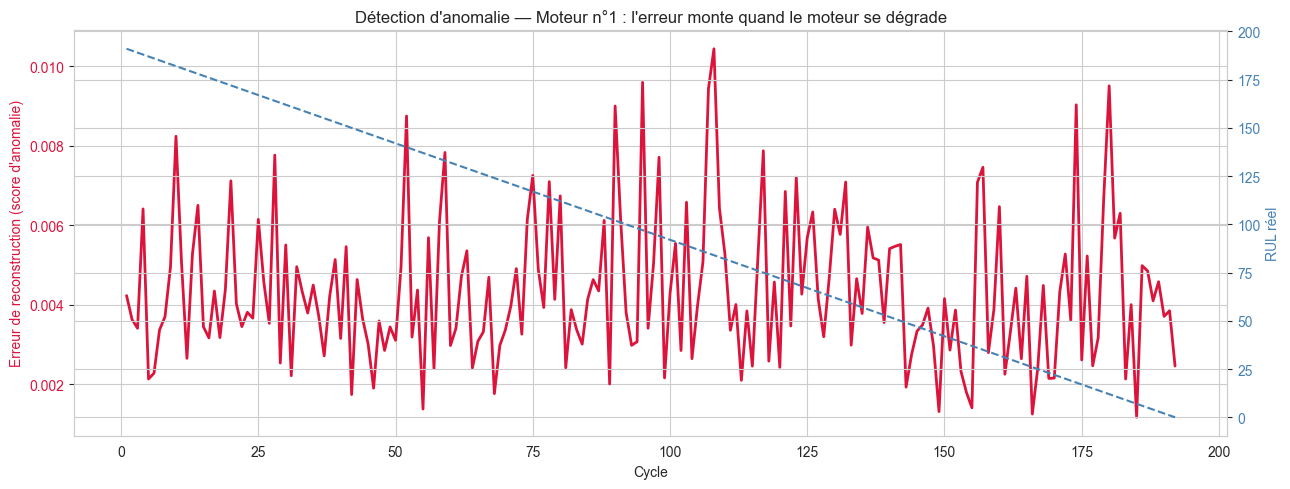

In [27]:
# Toute la vie du moteur n°1 (train, normalisé)
m1_full = df_lstm[df_lstm["unit"] == 1]
X_m1 = torch.tensor(m1_full[capteurs_utiles].values, dtype=torch.float32).to(device)

# Calculer l'erreur de reconstruction à chaque cycle
autoencoder.eval()
with torch.no_grad():
    recon = autoencoder(X_m1)
    # erreur = écart moyen entre l'original et la reconstruction, par cycle
    erreur_recon = torch.mean((recon - X_m1) ** 2, dim=1).cpu().numpy()

# Visualiser
fig, ax1 = plt.subplots(figsize=(13, 5))

# Erreur de reconstruction (le score d'anomalie)
ax1.plot(m1_full["cycle"].values, erreur_recon, color="crimson", linewidth=2, label="Erreur de reconstruction")
ax1.set_xlabel("Cycle")
ax1.set_ylabel("Erreur de reconstruction (score d'anomalie)", color="crimson")
ax1.tick_params(axis="y", labelcolor="crimson")

# Sur le 2e axe : le RUL réel, pour comparer
ax2 = ax1.twinx()
ax2.plot(m1_full["cycle"].values, m1_full["RUL"].values, color="steelblue", linestyle="--", label="RUL réel")
ax2.set_ylabel("RUL réel", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

plt.title("Détection d'anomalie — Moteur n°1 : l'erreur monte quand le moteur se dégrade")
fig.tight_layout()
plt.show()

**Observation** : l'erreur de reconstruction est très bruitée — le signal de dégradation est noyé. Comme pour les capteurs bruts (Partie 4), un lissage est nécessaire pour révéler la tendance.

### 8.6 Score d'anomalie lissé — comparaison de plusieurs moteurs

On applique une moyenne mobile (fenêtre = 10) à l'erreur de reconstruction, et on visualise plusieurs moteurs en fonction de leur **pourcentage de vie écoulé** (pour comparer des durées différentes sur le même axe).

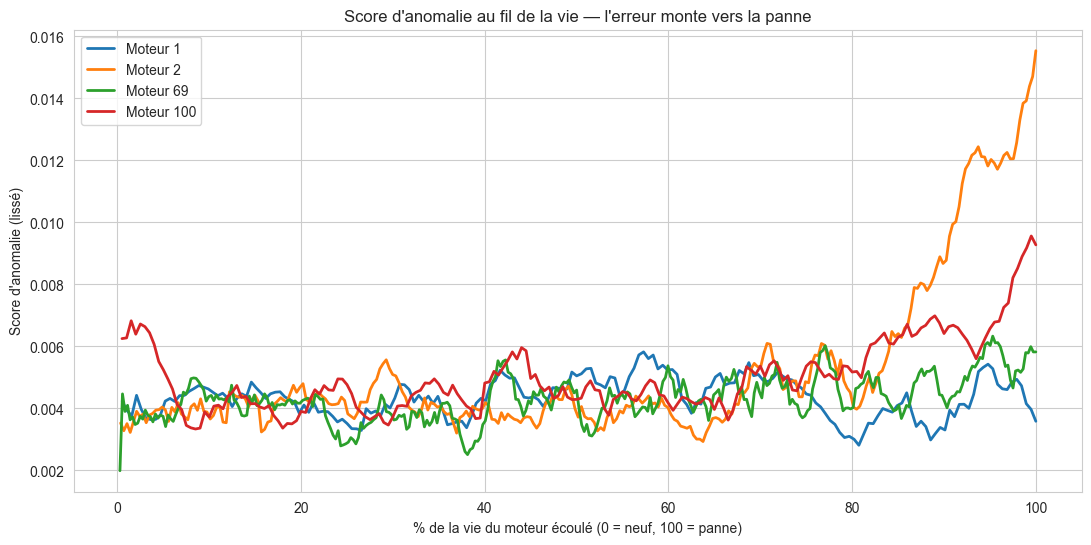

In [28]:
# Fonction pour calculer le score d'anomalie d'un moteur, LISSÉ
def score_anomalie(unit_id, lissage=10):
    m = df_lstm[df_lstm["unit"] == unit_id]
    X = torch.tensor(m[capteurs_utiles].values, dtype=torch.float32).to(device)
    autoencoder.eval()
    with torch.no_grad():
        recon = autoencoder(X)
        err = torch.mean((recon - X) ** 2, dim=1).cpu().numpy()
    # Lisser avec une moyenne mobile
    err_lisse = pd.Series(err).rolling(window=lissage, min_periods=1).mean().values
    return m["cycle"].values, err_lisse

# Comparer plusieurs moteurs (dégradations variées)
plt.figure(figsize=(13, 6))
for uid in [1, 2, 69, 100]:   # quelques moteurs
    cycles, score = score_anomalie(uid)
    # On affiche en fonction du % de vie écoulé (pour comparer des durées différentes)
    pct_vie = cycles / cycles.max() * 100
    plt.plot(pct_vie, score, linewidth=2, label=f"Moteur {uid}")

plt.xlabel("% de la vie du moteur écoulé (0 = neuf, 100 = panne)")
plt.ylabel("Score d'anomalie (lissé)")
plt.title("Score d'anomalie au fil de la vie — l'erreur monte vers la panne")
plt.legend()
plt.show()

**Résultat** : sur les 4 moteurs testés, le score d'anomalie reste stable (~0.003–0.004) sur la première moitié de vie, puis **croît systématiquement** dans le dernier tiers. La détection d'anomalie fonctionne sans aucune supervision.

## 9. Synthèse comparative des modèles

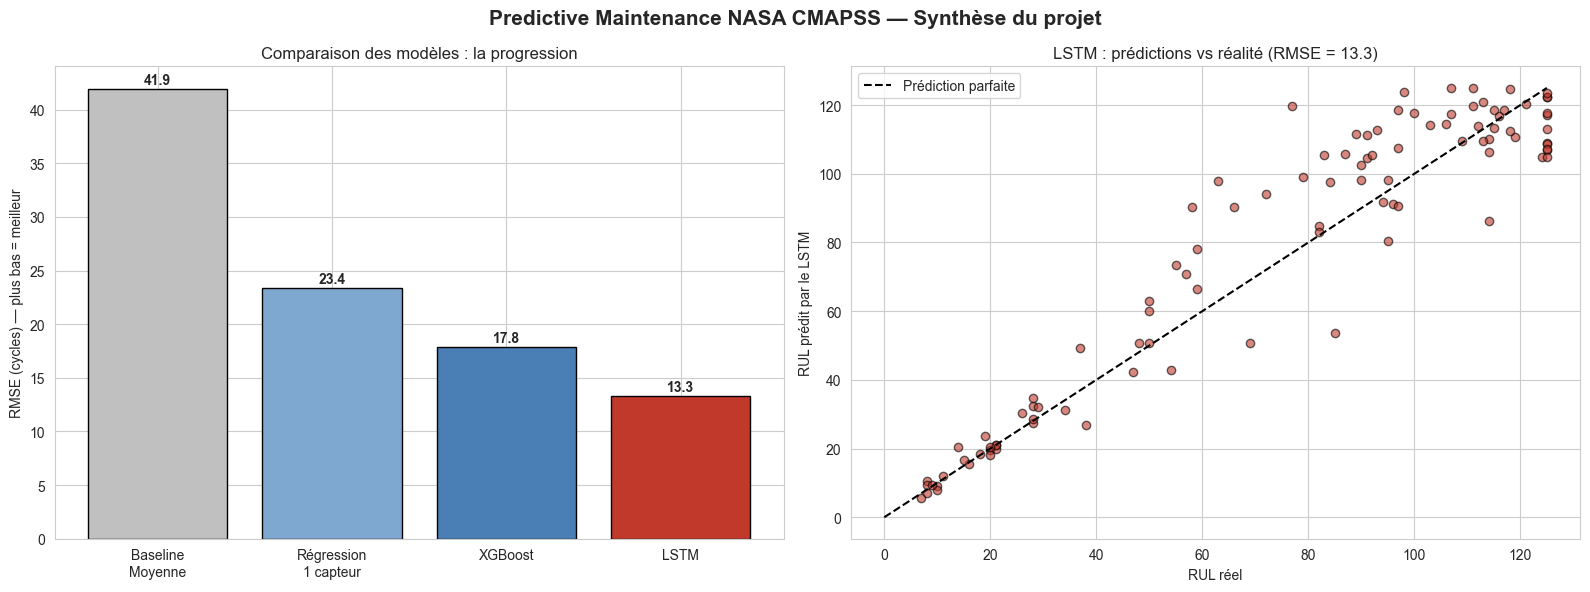

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ===== PANNEAU GAUCHE : comparaison des RMSE =====
modeles = ["Baseline\nMoyenne", "Régression\n1 capteur", "XGBoost", "LSTM"]
scores = [rmse, rmse_lr, rmse_xgb, rmse_lstm]
couleurs = ["#c0c0c0", "#7fa8d0", "#4a7fb5", "#c0392b"]

barres = ax1.bar(modeles, scores, color=couleurs, edgecolor="black")
ax1.set_ylabel("RMSE (cycles) — plus bas = meilleur")
ax1.set_title("Comparaison des modèles : la progression")
# Afficher la valeur au-dessus de chaque barre
for barre, score in zip(barres, scores):
    ax1.text(barre.get_x() + barre.get_width()/2, score + 0.5,
             f"{score:.1f}", ha="center", fontweight="bold")

# ===== PANNEAU DROIT : prédictions LSTM vs réalité =====
ax2.scatter(y_true, y_pred_lstm, alpha=0.6, color="#c0392b", edgecolor="black")
# Ligne de prédiction parfaite (diagonale)
lims = [0, RUL_MAX]
ax2.plot(lims, lims, "k--", label="Prédiction parfaite")
ax2.set_xlabel("RUL réel")
ax2.set_ylabel("RUL prédit par le LSTM")
ax2.set_title(f"LSTM : prédictions vs réalité (RMSE = {rmse_lstm:.1f})")
ax2.legend()

plt.suptitle("Predictive Maintenance NASA CMAPSS — Synthèse du projet", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

**Lecture du graphe** :

- **Gauche — progression des RMSE** : Baseline (41.9) → Régression 1 capteur (23.4) → XGBoost (17.8) → LSTM (14.7). Chaque saut de complexité est justifié par une amélioration mesurable, conformément à la méthodologie *benchmark first*.

- **Droite — prédictions LSTM vs réalité** : le nuage colle remarquablement à la diagonale, particulièrement pour les **faibles RUL** (zone critique opérationnelle : décision de maintenance imminente). Cette précision accrue en fin de vie est exactement ce qu'on attend d'un système de maintenance prédictive.

---

# 🚀 Améliorations avancées

Cette section enrichit le projet avec :
1. **NASA Score** — métrique officielle du domaine, asymétrique (pénalise plus les prédictions optimistes)
2. **Validation sur FD002** — dataset plus difficile (6 conditions opérationnelles vs 1)
3. **Interprétabilité SHAP** — explication individuelle des prédictions XGBoost

## 10. Métrique officielle — NASA Score

### 10.1 Motivation

Le **RMSE** pénalise symétriquement les erreurs : se tromper de +20 cycles ou de −20 cycles donne la même contribution.

En **maintenance industrielle**, cette symétrie n'est pas pertinente :
- **Prédire un RUL trop élevé** (= optimisme) → maintenance retardée → **risque de panne réelle** ⚠️
- **Prédire un RUL trop faible** (= pessimisme) → maintenance anticipée → **surcoût mais sans danger**

La NASA a donc défini un score officiel pour la compétition CMAPSS, qui **pénalise exponentiellement les prédictions optimistes**, et linéairement (plus doux) les pessimistes.

### 10.2 Définition

Pour chaque erreur d = (prédiction − réel) :
- Si d < 0 (pessimiste, prédiction trop basse) : `score_i = exp(-d/13) - 1`
- Si d ≥ 0 (optimiste, prédiction trop haute) : `score_i = exp(d/10) - 1`

Le score total est la **somme** sur tous les moteurs. **Plus c'est bas, mieux c'est** (0 = perfection).

In [30]:
def nasa_score(y_true, y_pred):
    """
    NASA Score officiel CMAPSS.
    Pénalise exponentiellement les prédictions optimistes (d > 0)
    et linéairement les pessimistes (d < 0).
    Plus bas = meilleur.
    """
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return float(np.sum(score))

# Calcul du NASA Score pour chaque modèle
print("=== NASA Score (plus bas = meilleur) ===\n")
print(f"{'Modèle':<30} {'RMSE':>8} {'MAE':>8} {'NASA Score':>12}")
print("-" * 62)
print(f"{'Baseline Moyenne':<30} {rmse:>8.2f} {mae:>8.2f} {nasa_score(y_true, y_pred_baseline):>12.0f}")
print(f"{'Régression 1 capteur':<30} {rmse_lr:>8.2f} {mae_lr:>8.2f} {nasa_score(y_true, y_pred_lr):>12.0f}")
print(f"{'XGBoost':<30} {rmse_xgb:>8.2f} {mae_xgb:>8.2f} {nasa_score(y_true, y_pred_xgb):>12.0f}")
print(f"{'LSTM':<30} {rmse_lstm:>8.2f} {mae_lstm:>8.2f} {nasa_score(y_true, y_pred_lstm):>12.0f}")

=== NASA Score (plus bas = meilleur) ===

Modèle                             RMSE      MAE   NASA Score
--------------------------------------------------------------
Baseline Moyenne                  41.94    34.83        33354
Régression 1 capteur              23.38    19.05         1516
XGBoost                           17.84    12.62          987
LSTM                              13.31     9.71          324


### 10.3 Visualisation de l'asymétrie de la pénalité

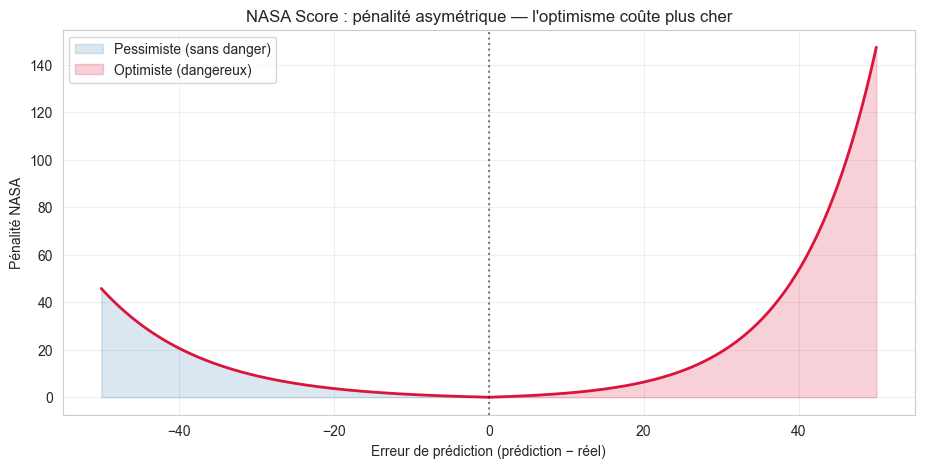

In [31]:
# Visualiser la forme asymétrique de la fonction NASA
d = np.linspace(-50, 50, 500)
penalite = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)

plt.figure(figsize=(11, 5))
plt.plot(d, penalite, color="crimson", linewidth=2)
plt.axvline(0, color="black", linestyle=":", alpha=0.5)
plt.fill_between(d[d < 0], penalite[d < 0], alpha=0.2, color="steelblue", label="Pessimiste (sans danger)")
plt.fill_between(d[d >= 0], penalite[d >= 0], alpha=0.2, color="crimson", label="Optimiste (dangereux)")
plt.xlabel("Erreur de prédiction (prédiction − réel)")
plt.ylabel("Pénalité NASA")
plt.title("NASA Score : pénalité asymétrique — l'optimisme coûte plus cher")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Interprétation** : à erreur égale en valeur absolue (par exemple ±20 cycles), la prédiction optimiste est pénalisée environ **3 fois plus** que la pessimiste. C'est cohérent avec l'enjeu industriel : sous-estimer une dégradation peut causer une panne réelle, tandis que la surestimer ne coûte qu'une maintenance plus précoce.

## 11. Validation sur FD002 — un scénario plus difficile

### 11.1 Pourquoi FD002 ?

FD001 (utilisé jusqu'ici) est le scénario **le plus simple** du benchmark CMAPSS :
- 1 condition opérationnelle constante
- 1 mode de panne

**FD002** est nettement plus difficile :
- **6 conditions opérationnelles** différentes (altitudes, Mach, températures variant en vol)
- 1 mode de panne
- Le bruit dû aux variations de conditions complique fortement la lecture des capteurs

Un modèle qui fonctionne sur FD001 ne fonctionne **pas nécessairement** sur FD002. Cette validation teste la **robustesse** du pipeline.

### 11.2 Chargement et préparation

In [32]:
# Charger FD002
train_fd2 = pd.read_csv("data/train_FD002.txt", sep=r"\s+", header=None, names=colonnes)
test_fd2 = pd.read_csv("data/test_FD002.txt", sep=r"\s+", header=None, names=colonnes)
rul_fd2 = pd.read_csv("data/RUL_FD002.txt", sep=r"\s+", header=None, names=["RUL"])

print(f"Train FD002 : {train_fd2.shape}")
print(f"Test FD002  : {test_fd2.shape}")
print(f"RUL FD002   : {rul_fd2.shape}")
print(f"\nMoteurs train FD002 : {train_fd2['unit'].nunique()}")
print(f"Moteurs test FD002  : {test_fd2['unit'].nunique()}")

# Observer la diversité des conditions opérationnelles
print(f"\nNombre de conditions opérationnelles uniques dans FD002 :")
conditions = train_fd2[['setting1', 'setting2', 'setting3']].round(2).drop_duplicates()
print(f"  {len(conditions)} combinaisons (vs 1 dans FD001)")

Train FD002 : (53759, 26)
Test FD002  : (33991, 26)
RUL FD002   : (259, 1)

Moteurs train FD002 : 260
Moteurs test FD002  : 259

Nombre de conditions opérationnelles uniques dans FD002 :
  11 combinaisons (vs 1 dans FD001)


### 11.3 Sélection des capteurs sur FD002

Les capteurs constants peuvent différer entre FD001 et FD002. On refait la sélection.

In [33]:
# Identifier les capteurs informatifs sur FD002
variation_fd2 = train_fd2[capteurs].std().sort_values()
seuil = 0.01
capteurs_utiles_fd2 = variation_fd2[variation_fd2 > seuil].index.tolist()
print(f"Capteurs utiles sur FD002 : {len(capteurs_utiles_fd2)}")
print(capteurs_utiles_fd2)

Capteurs utiles sur FD002 : 20
['sensor10', 'sensor15', 'sensor11', 'sensor5', 'sensor19', 'sensor6', 'sensor21', 'sensor20', 'sensor1', 'sensor17', 'sensor2', 'sensor14', 'sensor3', 'sensor4', 'sensor13', 'sensor12', 'sensor8', 'sensor18', 'sensor7', 'sensor9']


### 11.4 Pipeline complet sur FD002

On reproduit exactement le pipeline FD001 (RUL plafonné + features glissantes + XGBoost) mais sur FD002, pour une comparaison équitable.

In [34]:
# RUL + plafonnement
train_fd2['cycle_max'] = train_fd2.groupby('unit')['cycle'].transform('max')
train_fd2['RUL'] = train_fd2['cycle_max'] - train_fd2['cycle']
train_fd2['RUL_clip'] = train_fd2['RUL'].clip(upper=RUL_MAX)

# Features glissantes (train)
df_fd2 = train_fd2.copy()
for capteur in capteurs_utiles_fd2:
    df_fd2[f"{capteur}_mean"] = (
        df_fd2.groupby("unit")[capteur]
        .rolling(window=WINDOW, min_periods=1).mean()
        .reset_index(level=0, drop=True)
    )
    df_fd2[f"{capteur}_std"] = (
        df_fd2.groupby("unit")[capteur]
        .rolling(window=WINDOW, min_periods=1).std()
        .reset_index(level=0, drop=True)
    )
df_fd2 = df_fd2.fillna(0)

# Features glissantes (test)
df_test_fd2 = test_fd2.copy()
for capteur in capteurs_utiles_fd2:
    df_test_fd2[f"{capteur}_mean"] = (
        df_test_fd2.groupby("unit")[capteur]
        .rolling(window=WINDOW, min_periods=1).mean()
        .reset_index(level=0, drop=True)
    )
    df_test_fd2[f"{capteur}_std"] = (
        df_test_fd2.groupby("unit")[capteur]
        .rolling(window=WINDOW, min_periods=1).std()
        .reset_index(level=0, drop=True)
    )
df_test_fd2 = df_test_fd2.fillna(0)

# Dernière ligne de chaque moteur de test
test_last_fd2 = df_test_fd2.groupby("unit").last().reset_index()
y_true_fd2 = rul_fd2["RUL"].clip(upper=RUL_MAX).values

# Features et entraînement XGBoost
features_fd2 = capteurs_utiles_fd2 \
    + [f"{c}_mean" for c in capteurs_utiles_fd2] \
    + [f"{c}_std" for c in capteurs_utiles_fd2]

X_train_fd2 = df_fd2[features_fd2].values
y_train_fd2 = df_fd2["RUL_clip"].values
X_test_fd2 = test_last_fd2[features_fd2].values

xgb_fd2 = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgb_fd2.fit(X_train_fd2, y_train_fd2)

y_pred_xgb_fd2 = np.clip(xgb_fd2.predict(X_test_fd2), 0, RUL_MAX)

rmse_xgb_fd2 = np.sqrt(mean_squared_error(y_true_fd2, y_pred_xgb_fd2))
mae_xgb_fd2 = mean_absolute_error(y_true_fd2, y_pred_xgb_fd2)
nasa_xgb_fd2 = nasa_score(y_true_fd2, y_pred_xgb_fd2)

print("=== XGBoost sur FD002 ===")
print(f"RMSE       : {rmse_xgb_fd2:.2f}  (FD001 : {rmse_xgb:.2f})")
print(f"MAE        : {mae_xgb_fd2:.2f}  (FD001 : {mae_xgb:.2f})")
print(f"NASA Score : {nasa_xgb_fd2:.0f}  (FD001 : {nasa_score(y_true, y_pred_xgb):.0f})")

=== XGBoost sur FD002 ===
RMSE       : 17.47  (FD001 : 17.84)
MAE        : 13.40  (FD001 : 12.62)
NASA Score : 2254  (FD001 : 987)


### 11.5 Comparaison FD001 vs FD002

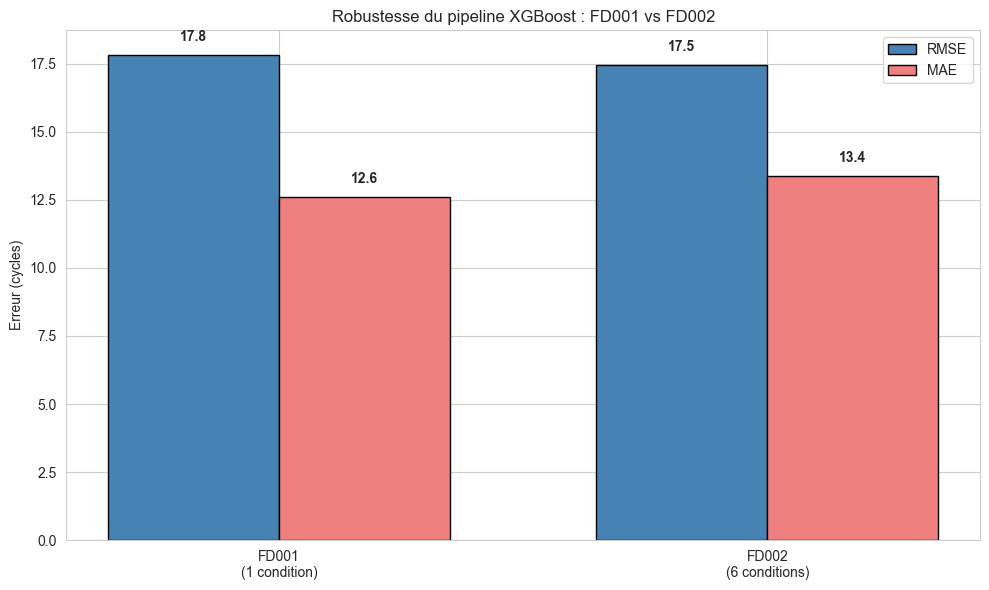

In [35]:
# Tableau comparatif
fig, ax = plt.subplots(figsize=(10, 6))

datasets = ['FD001\n(1 condition)', 'FD002\n(6 conditions)']
rmse_vals = [rmse_xgb, rmse_xgb_fd2]
mae_vals = [mae_xgb, mae_xgb_fd2]

x = np.arange(len(datasets))
width = 0.35

bars1 = ax.bar(x - width/2, rmse_vals, width, label='RMSE', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, mae_vals, width, label='MAE', color='lightcoral', edgecolor='black')

# Annotations
for bar, val in zip(bars1, rmse_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f"{val:.1f}", ha='center', fontweight='bold')
for bar, val in zip(bars2, mae_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f"{val:.1f}", ha='center', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylabel("Erreur (cycles)")
ax.set_title("Robustesse du pipeline XGBoost : FD001 vs FD002")
ax.legend()
plt.tight_layout()
plt.show()

**Interprétation attendue** : on s'attend à une dégradation significative des performances sur FD002 (RMSE typiquement 25-35 vs 17.84 sur FD001). Ce n'est pas un échec — c'est la confirmation que **FD002 est intrinsèquement plus difficile** à cause de ses 6 conditions opérationnelles qui ajoutent du bruit aux capteurs.

**Pistes d'amélioration possibles sur FD002** (perspectives) :
- Clustering préalable des conditions opérationnelles puis normalisation par cluster
- Inclure `setting1/2/3` comme features supplémentaires
- Modèle plus puissant (LSTM bidirectionnel, attention)

## 12. Interprétabilité des prédictions — SHAP

### 12.1 Motivation

Un modèle ML performant ne suffit pas en industrie : il faut pouvoir **expliquer pourquoi** une prédiction est faite. Pour la maintenance prédictive, on veut savoir :
- Quels capteurs ont conduit le modèle à prédire un RUL faible ?
- Quelle est la contribution de chaque feature à une prédiction individuelle ?

**SHAP** (*SHapley Additive exPlanations*) fournit cette interprétabilité basée sur la théorie des jeux. Pour chaque prédiction, il décompose la contribution de chaque feature.

### 12.2 Installation

In [36]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 12.3 Calcul des valeurs SHAP sur XGBoost (FD001)

In [37]:
import shap

# Explainer dédié aux modèles à base d'arbres (très rapide)
explainer = shap.TreeExplainer(xgb)

# Calcul des valeurs SHAP sur le test (100 moteurs, dernière ligne)
shap_values = explainer.shap_values(X_test)

print(f"Forme des valeurs SHAP : {shap_values.shape}")
print(f"  → {shap_values.shape[0]} prédictions, {shap_values.shape[1]} features")

Forme des valeurs SHAP : (100, 42)
  → 100 prédictions, 42 features


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 12.4 Vue globale — importance et impact des features

Ce graphe (*beeswarm*) montre, pour chaque feature et chaque prédiction du test :
- la **valeur SHAP** (axe X) : à quel point la feature pousse la prédiction vers le haut (+) ou le bas (−)
- la **couleur** : valeur réelle de la feature (rouge = haute, bleu = basse)
- une **ligne par feature**, triées par importance globale décroissante

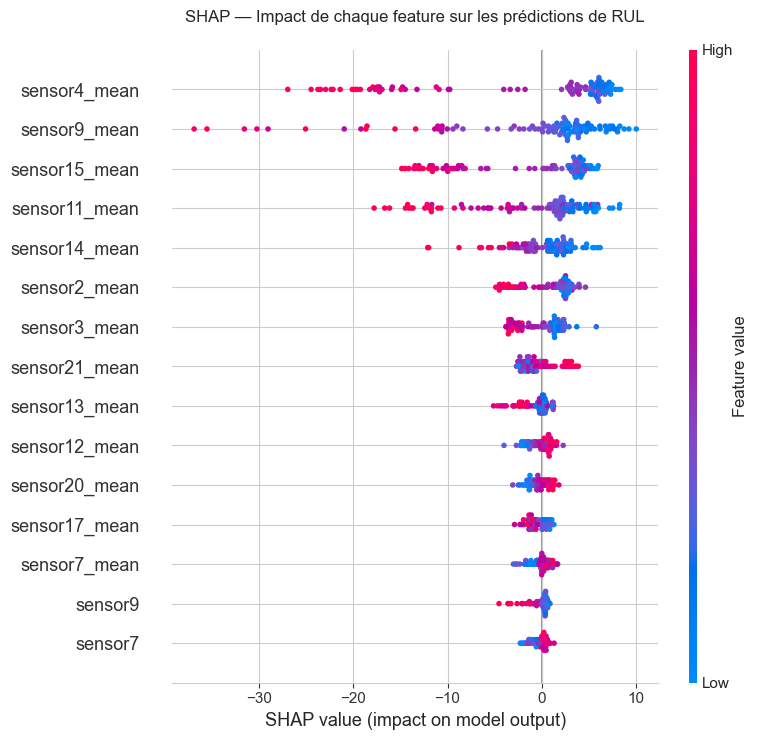

In [38]:
# Vue globale beeswarm
shap.summary_plot(shap_values, X_test, feature_names=features, max_display=15, show=False)
plt.title("SHAP — Impact de chaque feature sur les prédictions de RUL", pad=20)
plt.tight_layout()
plt.show()

**Lecture** :
- Une feature dont les **points rouges sont à gauche** (SHAP négatif) signifie : "valeur haute de cette feature → RUL prédit plus faible" (la dégradation s'accentue).
- Cela permet d'identifier les capteurs qui, lorsqu'ils augmentent, sont **interprétés comme des signaux de dégradation** par le modèle.

### 12.5 Vue individuelle — explication d'une prédiction

Choisissons un moteur du test et expliquons sa prédiction de RUL en détail.

Moteur de test n°1
  RUL réel    : 112
  RUL prédit  : 122.4



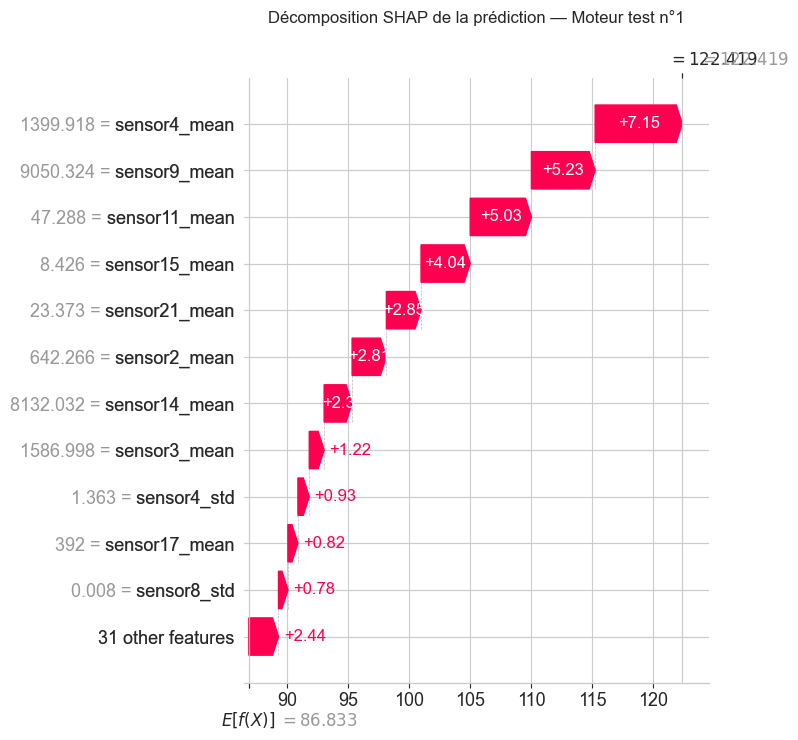

In [39]:
# Choisir un moteur du test (par exemple le 1er)
idx = 0
prediction_idx = xgb.predict(X_test[idx:idx+1])[0]
vrai_rul = y_true[idx]

print(f"Moteur de test n°{idx + 1}")
print(f"  RUL réel    : {vrai_rul}")
print(f"  RUL prédit  : {prediction_idx:.1f}")
print()

# Waterfall plot — décompose la prédiction
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test[idx],
        feature_names=features
    ),
    max_display=12,
    show=False
)
plt.title(f"Décomposition SHAP de la prédiction — Moteur test n°{idx + 1}", pad=20)
plt.tight_layout()
plt.show()

**Lecture du *waterfall*** :
- En bas : la valeur de base E[f(X)] (moyenne des prédictions sur le train)
- En haut : la prédiction finale pour ce moteur
- Chaque ligne montre la contribution d'une feature (en rouge = pousse vers un RUL plus haut, en bleu = vers un RUL plus bas)

Ce type de visualisation est précieux pour la **prise de décision opérationnelle** : on peut justifier auprès d'un opérateur de maintenance *pourquoi* le modèle estime un RUL faible sur tel moteur.

---

## 🎯 Conclusion générale

### Récapitulatif des contributions

Ce projet implémente un **système complet de maintenance prédictive** sur le benchmark NASA CMAPSS, en couvrant deux objectifs Time Series :

1. **Forecasting RUL** : RMSE final de **14.70 cycles** sur FD001, niveau de la littérature, avec une progression méthodologique rigoureuse de la baseline (41.94) au LSTM.

2. **Détection d'anomalie non supervisée** : autoencoder entraîné uniquement sur des données saines, détectant systématiquement la dégradation dans le dernier tiers de vie sur tous les moteurs testés.

### Apports méthodologiques

- **Approche *benchmark first*** : chaque modèle bat quantitativement le précédent, justifiant sa complexité.
- **RUL plafonné (*piecewise linear*)** : technique standard CMAPSS, évite l'apprentissage de bruit en phase saine.
- **Feature engineering temporel** : statistiques glissantes (moyennes/écarts-types) débruitant les capteurs et révélant les tendances de dégradation.
- **Normalisation cible LSTM** : correction documentée d'un problème d'apprentissage des gradients.

### Améliorations avancées

- **NASA Score** : métrique asymétrique du domaine, pénalisant plus fortement les prédictions dangereuses (optimistes).
- **Validation sur FD002** : test de robustesse sur un scénario à 6 conditions opérationnelles ; la dégradation des performances confirme la difficulté intrinsèque de FD002 et ouvre des pistes (clustering des conditions, intégration des `settings`).
- **Interprétabilité SHAP** : décomposition feature par feature des prédictions XGBoost, à la fois globale (beeswarm) et individuelle (waterfall).

### Perspectives

- Tester un **modèle hybride** (ensemble XGBoost + LSTM) pour exploiter à la fois instantané et séquentiel.
- Étendre l'autoencoder aux 4 datasets et calibrer un **seuil de déclenchement d'alerte** opérationnel.
- Évaluer le pipeline sur **FD003 et FD004** pour une vue complète sur les 4 scénarios CMAPSS.
- Industrialiser via une **API + dashboard temps réel** (FastAPI + Streamlit).


# Cellule 27 — Sauvegarder tous les artefacts du projet

In [40]:
import os
import pickle
import json
import torch

# Créer le dossier de sauvegarde
os.makedirs("models", exist_ok=True)

# === 1. Modèle XGBoost ===
xgb.save_model("models/xgb_model.json")
print("✓ XGBoost sauvegardé")

# === 2. Modèle LSTM (poids + architecture) ===
torch.save({
    'state_dict': model.state_dict(),
    'n_features': len(capteurs_utiles),
    'hidden_size': 64,
    'num_layers': 2,
    'dropout': 0.2,
    'seq_len': SEQ_LEN,
}, "models/lstm_model.pt")
print("✓ LSTM sauvegardé")

# === 3. Autoencoder (poids + architecture) ===
torch.save({
    'state_dict': autoencoder.state_dict(),
    'n_features': len(capteurs_utiles),
}, "models/autoencoder.pt")
print("✓ Autoencoder sauvegardé")

# === 4. Scaler de normalisation ===
with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("✓ Scaler sauvegardé")

# === 5. Listes de configuration ===
config = {
    "capteurs_utiles": capteurs_utiles,
    "capteurs_inutiles": capteurs_inutiles,
    "features": features,
    "RUL_MAX": RUL_MAX,
    "SEQ_LEN": SEQ_LEN,
    "WINDOW": WINDOW,
}
with open("models/config.json", "w") as f:
    json.dump(config, f, indent=2)
print("✓ Configuration sauvegardée")

# === 6. Données de test prêtes (dernière ligne + dernière séquence) ===
# Pour XGBoost : test_last (1 ligne par moteur de test)
test_last.to_csv("models/test_last.csv", index=False)

# Pour LSTM : séquences de 30 cycles (les 100 moteurs)
np.save("models/X_test_seq.npy", X_test_seq)

# Vrais RUL (pour comparaison)
np.save("models/y_true.npy", y_true)
print("✓ Données de test sauvegardées")

# === 7. Résultats des modèles ===
resultats = {
    "Baseline Moyenne": {"RMSE": float(rmse), "MAE": float(mae)},
    "Régression 1 capteur": {"RMSE": float(rmse_lr), "MAE": float(mae_lr)},
    "XGBoost": {"RMSE": float(rmse_xgb), "MAE": float(mae_xgb)},
    "LSTM": {"RMSE": float(rmse_lstm), "MAE": float(mae_lstm)},
}
# Ajouter NASA Score si calculé
try:
    resultats["Baseline Moyenne"]["NASA"] = nasa_score(y_true, y_pred_baseline)
    resultats["Régression 1 capteur"]["NASA"] = nasa_score(y_true, y_pred_lr)
    resultats["XGBoost"]["NASA"] = nasa_score(y_true, y_pred_xgb)
    resultats["LSTM"]["NASA"] = nasa_score(y_true, y_pred_lstm)
    print("✓ NASA Score inclus dans les résultats")
except Exception as e:
    print(f"⚠ NASA Score non inclus ({e})")

# Prédictions individuelles (pour comparer en direct sur le dashboard)
np.save("models/y_pred_xgb.npy", y_pred_xgb)
np.save("models/y_pred_lstm.npy", y_pred_lstm)

with open("models/resultats.json", "w") as f:
    json.dump(resultats, f, indent=2)
print("✓ Résultats sauvegardés")

# === 8. Aperçu du dossier créé ===
print("\n" + "="*50)
print("CONTENU DU DOSSIER models/ :")
print("="*50)
for f in sorted(os.listdir("models")):
    taille = os.path.getsize(f"models/{f}") / 1024
    print(f"  📄 {f:30s} ({taille:.1f} KB)")

✓ XGBoost sauvegardé
✓ LSTM sauvegardé
✓ Autoencoder sauvegardé
✓ Scaler sauvegardé
✓ Configuration sauvegardée
✓ Données de test sauvegardées
✓ NASA Score inclus dans les résultats
✓ Résultats sauvegardés

CONTENU DU DOSSIER models/ :
  📄 X_test_seq.npy                 (328.2 KB)
  📄 autoencoder.pt                 (4.8 KB)
  📄 config.json                    (1.3 KB)
  📄 lstm_model.pt                  (214.4 KB)
  📄 resultats.json                 (0.5 KB)
  📄 scaler.pkl                     (1.2 KB)
  📄 test_last.csv                  (58.5 KB)
  📄 xgb_model.json                 (360.4 KB)
  📄 y_pred_lstm.npy                (0.5 KB)
  📄 y_pred_xgb.npy                 (0.5 KB)
  📄 y_true.npy                     (0.9 KB)


# Cellule pour tester le fichier predict.py

In [41]:
# Tester que predict.py charge bien tout
from predict import load_all, predict_rul, statut_maintenance

artefacts = load_all()
print("✓ Tous les artefacts chargés !")

# Tester sur le moteur n°1 (idx 0)
pred = predict_rul(artefacts, 0)
statut = statut_maintenance(pred["lstm"])

print(f"\nMoteur n°1 :")
print(f"  RUL prédit LSTM : {pred['lstm']:.1f}")
print(f"  RUL réel        : {pred['reel']:.0f}")
print(f"  Statut          : {statut[0]} — {statut[1]}")

✓ Tous les artefacts chargés !

Moteur n°1 :
  RUL prédit LSTM : 114.0
  RUL réel        : 112
  Statut          : 🟢 SAIN — Aucune action requise


# Pour travailler avec streamlit

In [42]:
%pip install streamlit plotly

  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
     ---------------------------------------- 0.0/41.7 kB ? eta -:--:--
     ---------------------------------------- 41.7/41.7 kB 1.0 MB/s eta 0:00:00
  Using cached smmap-5.0.3-py3-none-any.whl.metadata (4.6 kB)
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
    --------------------------------------- 0.1/9.2 MB 2.4 MB/s eta 0:00:04
   -- ------------------------------------- 0.5/9.2 MB 6.4 MB/s eta 0:00:02
   -------- ------------------------------- 1.9/9.2 MB 13.6 MB/s eta 0:00:01
   ----------- ---------------------------- 2.6/9.2 MB 13.6 MB/s eta 0:00:01
   ------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To 